In [33]:
import os
# os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [34]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import os
import pandas as pd
from utils.preprocess import *

In [35]:
import os
import sys
    
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper

In [36]:
import random
import umap
from models.modules import *

In [37]:
import matplotlib.pyplot as plt
%matplotlib inline

In [38]:
from scripts.run_model import *

In [39]:
%reload_ext autoreload
%autoreload 2

In [40]:
############################################################

In [41]:
from torchdyn.datasets import generate_moons

from torchcfm.conditional_flow_matching import *
from torchcfm.models.models import *
from torchcfm.utils import *

In [42]:
from simulate.simulate import *

In [ ]:
### SETTINGS ###

dataname = "s"
size = 5000
d = 5 #dummy dimension

In [44]:
############################################################

In [50]:
dic = {"s": sample_s,
       "points": sample_points,
       "diamond": sample_diamond,
       "omega": sample_omega}
adata = process_fake_data(size, d, dic[dataname])

In [51]:
adata

AnnData object with n_obs × n_vars = 4998 × 2
    obs: 'timepoint', 'gene_target', 'cell_type', 'cell_type_one_hot'
    uns: 'std', 'tree'
    obsm: 'X_pca'
    varm: 'PCs'

In [52]:
dataset = extract_paired_dataset(adata)

In [53]:
############################################################

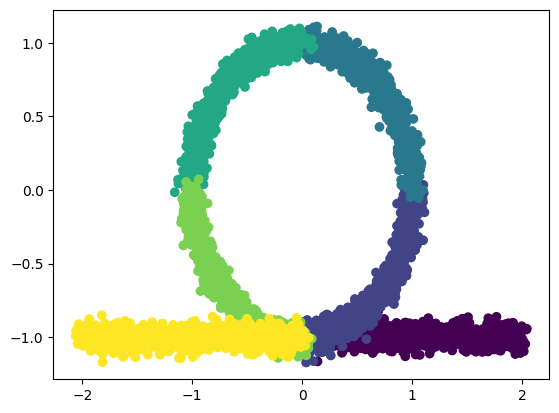

In [ ]:
samples = torch.from_numpy(adata.obsm['X_pca']).float()
fig, ax = plt.subplots()
# ax.scatter(samples[:,0], samples[:, 1])
ax.scatter(samples[:,0], samples[:, 1], c=adata.obs['timepoint'].astype(int).tolist())
plt.show()

In [ ]:
config = Config(
    {        
        "classifier_max_epochs": 2,
        "metric_max_epochs": 500,
        "embed_max_epochs": 1000,
        "flow_max_epochs": 1000,
        "lr": 1e-4,
        "dropout": 0.0,
        "pc_dim": d,
        "num_classes": adata.obs['cell_type'].nunique(),
        "hidden_dim": 256,
        "score_batch_size": 2048,
        "flow_batch_size": 512,
        "num_freq": 32,
        "num_layers": 4,
        "force_cpu": False,
        "detect_anomaly": False,
        "gradient_clip_val": 0,
        "loader_batch_size": 6,
        "warmup_steps": 0,
        "ema_decay": 1-1e-3,

        "metric": "mfm", #TODO: make the variables conditional?
        "K": 500,
        "kappa": 1.0,

        "use_finsler": False,
        
        "ot_in_embed": True,
        "fast_ot": False,
        
        "latent_dim": 100,

        "skip": False,
        "rescale": 0.5,

        "sigma": 0.05,
    }
)

project = "ffm-ipynb"

In [ ]:
classifier_model, metric_model, embed_model, flow_model = run_full_model(config, project, adata, dataset)

In [ ]:
#fix the wandb.run.summary bug?
def remove_all_forward_hooks(model):
    for module in model.modules():
        module._forward_hooks.clear()

remove_all_forward_hooks(classifier_model)
remove_all_forward_hooks(metric_model)
remove_all_forward_hooks(embed_model)
remove_all_forward_hooks(flow_model)

In [ ]:
#NOTE: only works for MFM
def visualize_metric(metric_model, samples, grid_steps=30):

    import torch, numpy as np, matplotlib.pyplot as plt
    from scipy.stats import gaussian_kde
    plt.close('all')

    m = torch.max(torch.abs(samples)).item() + 1.0
    xs = torch.linspace(-m,  m, steps=grid_steps)
    ys = torch.linspace(-m,  m, steps=grid_steps)
    xg, yg = torch.meshgrid(xs, ys, indexing='xy')
    z   = torch.stack([xg, yg], dim=-1).reshape(-1, 2)

    zeros = torch.zeros(z.shape[0], d-2, device=z.device, dtype=z.dtype)
    z = torch.cat([z, zeros], dim=1) 

    print(z.shape)
    print(metric_model.M(z.to('cuda')).detach().shape)

    E = metric_model.M(z.to('cuda')).detach().reshape(grid_steps, grid_steps).cpu()

    fig, ax = plt.subplots()

    contour = ax.contourf(xg, yg, -E, levels=100, cmap='inferno')
    ax.scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.005)
    ax.set_aspect('equal')
    fig.colorbar(contour, ax=ax, label="negative metric tensor")
    plt.show()

In [ ]:
if config.metric == "mfm":
    samples = torch.from_numpy(adata.obsm['X_pca']).float()
    visualize_metric(metric_model, samples)

In [ ]:
from torch.utils.data import TensorDataset, Sampler, DataLoader
from datasets.dataset import *

train_dataset = ShufflingDataset(dataset, 5)
train_dataloader = DataLoader(train_dataset, batch_size = config.loader_batch_size, shuffle=True)

In [ ]:
#GEO VALIDATION
for batch in train_dataloader:
    
    paths = embed_model.sample_geodesic(batch, points=200, ot_sample=False)

    break

fig, ax = plt.subplots(5, figsize=(8,8), sharex=True, sharey=True)
for i in range(5):
    traj = paths[:,i]
    ax[i].scatter(samples[:,0], samples[:, 1])
    ax[i].plot(traj[:, 0], traj[:, 1], marker=".", linestyle="-", alpha=0.7, lw=1.5, color='orange')
    ax[i].set(adjustable='box', aspect='equal')
plt.show()

In [ ]:
#EMBED VALIDATION
if config.metric == "cfm":
    x0, x1, _, _= embed_model._prepare_batch(batch)
    x0, x1 = x0[0], x1[0]
    true_dist = torch.norm(x0 - x1, dim = -1)
    f = embed_model.embed_fn
    learned_dist = torch.norm(f(x0).detach() - f(x1).detach(), dim=-1)
    print(torch.stack([true_dist, learned_dist], dim=1)[:10])

In [ ]:
#FLOW VALIDATION

num_samples = 500
steps = 500

In [ ]:
def plot_flow(t0):
    t1 = t0 + 1
    x = adata[adata.obs['timepoint'].astype(int) == t0].obsm['X_pca'][:num_samples]
    x = torch.from_numpy(x).float()
    traj = flow_model.sample_traj(x, t0, t1, num_samples, steps=steps)
    plot_trajectories(traj.cpu().numpy())

In [ ]:
plot_flow(0)

In [ ]:
plot_flow(1)

In [ ]:
plot_flow(2)

In [ ]:
plot_flow(3)

In [ ]:
plot_flow(4)